# 1.052/1.121/2.174J: Advancing Mechanics and Materials via Machine Learning  

### Sample neural network 

Install a few key libraries:

```csh
pip install matminer
pip install torchviz
pip install torchsummary
```

In [198]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#progress bar
from tqdm.notebook import tqdm

#sklearn - useful utils
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

#dataset loader
from matminer.datasets import load_dataset

import pandas as pd
from torchviz import make_dot

# Load dataset
df = load_dataset("elastic_tensor_2015")  # Elastic properties dataset

# Display available columns
print("Available columns:", df.columns.tolist())

# Select valid features based on available columns
features = ["nsites", "volume", "elastic_anisotropy", "poisson_ratio", "space_group"]
target = "K_VRH"  # Bulk modulus (VRH approximation)
#features = ["nsites", "volume", "elastic_anisotropy", "G_VRH",  ]
#target = "poisson_ratio"  # Bulk modulus (VRH approximation)

# Drop NaNs
df = df.dropna(subset=features + [target])

# Display dataset info
print("Dataset Shape:", df.shape)


Available columns: ['material_id', 'formula', 'nsites', 'space_group', 'volume', 'structure', 'elastic_anisotropy', 'G_Reuss', 'G_VRH', 'G_Voigt', 'K_Reuss', 'K_VRH', 'K_Voigt', 'poisson_ratio', 'compliance_tensor', 'elastic_tensor', 'elastic_tensor_original', 'cif', 'kpoint_density', 'poscar']
Dataset Shape: (1181, 20)


In [199]:
df.head()

,material_id,formula,nsites,space_group,volume,structure,elastic_anisotropy,G_Reuss,G_VRH,G_Voigt,K_Reuss,K_VRH,K_Voigt,poisson_ratio,compliance_tensor,elastic_tensor,elastic_tensor_original,cif,kpoint_density,poscar
0,mp-10003,Nb4CoSi,12,124,194.419802,"[[0.94814328 2.07280467 2.5112 ] Nb, [5.273...",0.030688,96.844535,97.141604,97.438674,194.267623,194.268884,194.270146,0.285701,"[[0.004385293093993, -0.0016070693558990002, -...","[[311.33514638650246, 144.45092552856926, 126....","[[311.33514638650246, 144.45092552856926, 126....",#\#CIF1.1\n###################################...,7000,Nb8 Co2 Si2\n1.0\n6.221780 0.000000 0.000000\n...
1,mp-10010,Al(CoSi)2,5,164,61.987320,"[[0. 0. 0.] Al, [1.96639263 1.13529553 0.75278...",0.266910,93.939650,96.252006,98.564362,173.647763,175.449907,177.252050,0.268105,"[[0.0037715428949660003, -0.000844229828709, -...","[[306.93357350984974, 88.02634955100905, 105.6...","[[306.93357350984974, 88.02634955100905, 105.6...",#\#CIF1.1\n###################################...,7000,Al1 Co2 Si2\n1.0\n3.932782 0.000000 0.000000\n...
2,mp-10015,SiOs,2,221,25.952539,"[[1.480346 1.480346 1.480346] Si, [0. 0. 0.] Os]",0.756489,120.962289,130.112955,139.263621,295.077545,295.077545,295.077545,0.307780,"[[0.0019959391925840004, -0.000433146670736000...","[[569.5291276937579, 157.8517489654999, 157.85...","[[569.5291276937579, 157.8517489654999, 157.85...",#\#CIF1.1\n###################################...,7000,Si1 Os1\n1.0\n2.960692 0.000000 0.000000\n0.00...
3,mp-10021,Ga,4,63,76.721433,"[[0. 1.09045794 0.84078375] Ga, [0. ...",2.376805,12.205989,15.101901,17.997812,49.025963,49.130670,49.235377,0.360593,"[[0.021647143908635, -0.005207263618160001, -0...","[[69.28798774976904, 34.7875015216915, 37.3877...","[[70.13259066665267, 40.60474945058445, 37.387...",#\#CIF1.1\n###################################...,7000,Ga4\n1.0\n2.803229 0.000000 0.000000\n0.000000...
4,mp-10025,SiRu2,12,62,160.300999,"[[1.0094265 4.24771709 2.9955487 ] Si, [3.028...",0.196930,100.110773,101.947798,103.784823,255.055257,256.768081,258.480904,0.324682,"[[0.00410214297725, -0.001272204332729, -0.001...","[[349.3767766177825, 186.67131003104407, 176.4...","[[407.4791016459293, 176.4759188081947, 213.83...",#\#CIF1.1\n###################################...,7000,Si4 Ru8\n1.0\n4.037706 0.000000 0.000000\n0.00...


### Scale data 

/var/folders/2b/9xb07zys42n4xcdd7487ywd40000gn/T/ipykernel_73650/1396086297.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(features, rotation=90)
/var/folders/2b/9xb07zys42n4xcdd7487ywd40000gn/T/ipykernel_73650/1396086297.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(features, rotation=90)


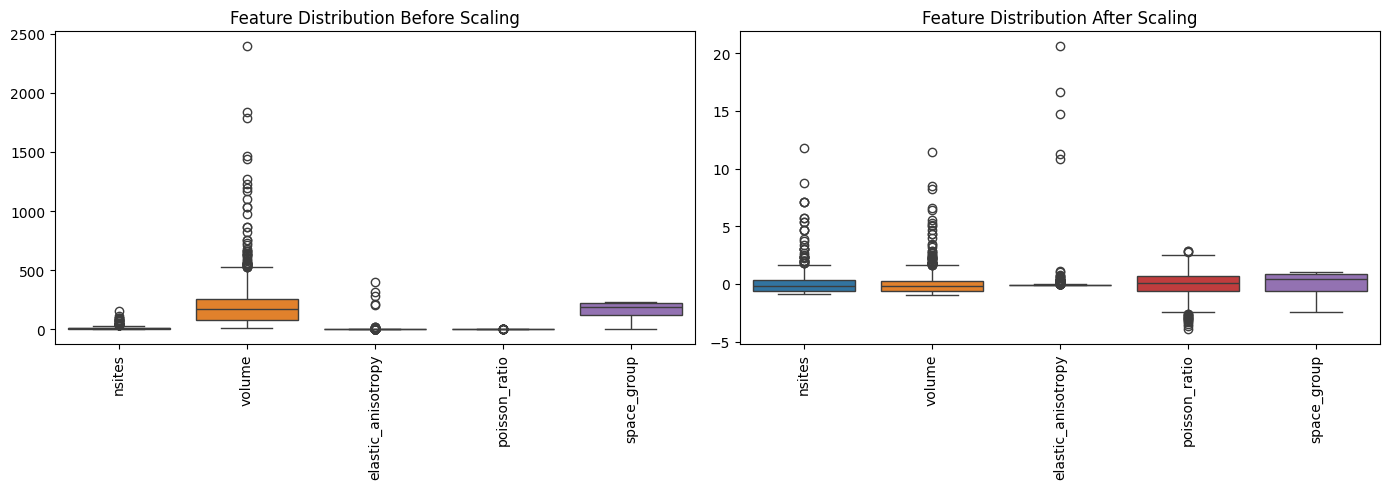

In [200]:

# Load dataset again (only for visualization)
df = load_dataset("elastic_tensor_2015").dropna(subset=features + [target])

# Extract raw feature values before scaling
X_raw = df[features].values

# Apply StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# Convert to DataFrame for easier plotting
df_raw = pd.DataFrame(X_raw, columns=features)
df_scaled = pd.DataFrame(X_scaled, columns=features)

# Plot before and after scaling
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before Scaling
sns.boxplot(data=df_raw, ax=axes[0])
axes[0].set_title("Feature Distribution Before Scaling")
axes[0].set_xticklabels(features, rotation=90)

# After Scaling
sns.boxplot(data=df_scaled, ax=axes[1])
axes[1].set_title("Feature Distribution After Scaling")
axes[1].set_xticklabels(features, rotation=90)

plt.tight_layout()
plt.show()

/var/folders/2b/9xb07zys42n4xcdd7487ywd40000gn/T/ipykernel_73650/2832971917.py:21: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(features, rotation=90)
/var/folders/2b/9xb07zys42n4xcdd7487ywd40000gn/T/ipykernel_73650/2832971917.py:26: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels(features, rotation=90)


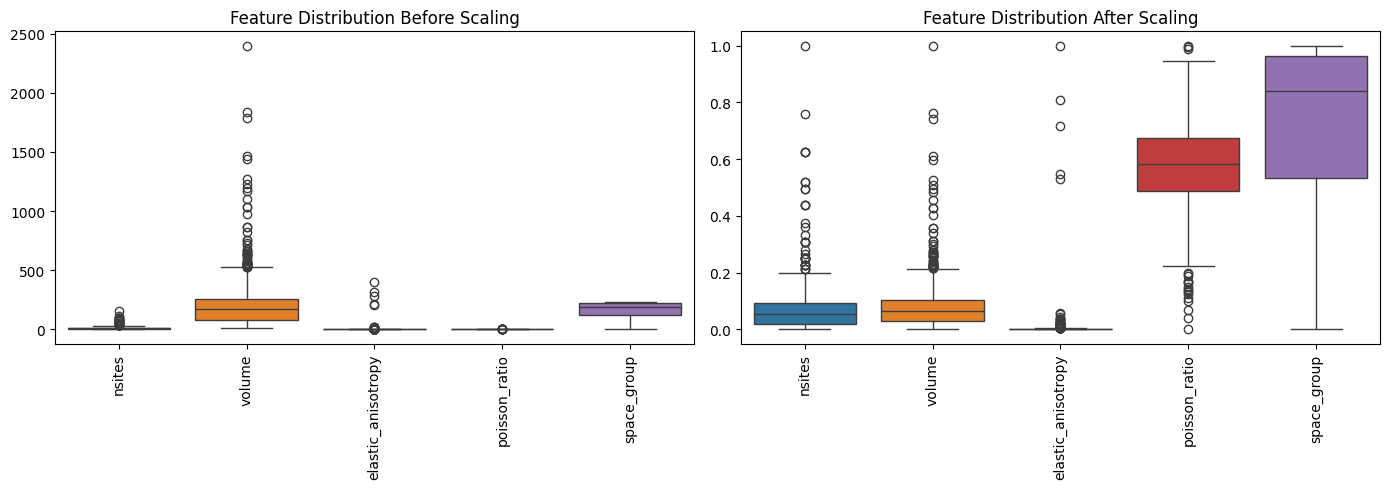

In [201]:

# Load dataset again (only for visualization)
df = load_dataset("elastic_tensor_2015").dropna(subset=features + [target])

# Extract raw feature values before scaling
X_raw = df[features].values

# Apply MinMaxScaler
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X_raw)

# Convert to DataFrame for easier plotting
df_raw = pd.DataFrame(X_raw, columns=features)
df_scaled = pd.DataFrame(X_scaled, columns=features)

# Plot before and after scaling
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Before Scaling
sns.boxplot(data=df_raw, ax=axes[0])
axes[0].set_title("Feature Distribution Before Scaling")
axes[0].set_xticklabels(features, rotation=90)

# After Scaling
sns.boxplot(data=df_scaled, ax=axes[1])
axes[1].set_title("Feature Distribution After Scaling")
axes[1].set_xticklabels(features, rotation=90)

plt.tight_layout()
plt.show()

In [202]:
# Convert to numpy arrays
X = df[features].values
y = df[target].values.reshape(-1, 1)

# Split into training and validation sets
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train = scaler_X.fit_transform(X_train)
X_val = scaler_X.transform(X_val)
y_train = scaler_y.fit_transform(y_train)
y_val = scaler_y.transform(y_val)

# Convert to PyTorch tensors
X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train, dtype=torch.float32)
X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val, dtype=torch.float32)
 

In [203]:
X.shape, y.shape

((1181, 5), (1181, 1))

### Define neural network 

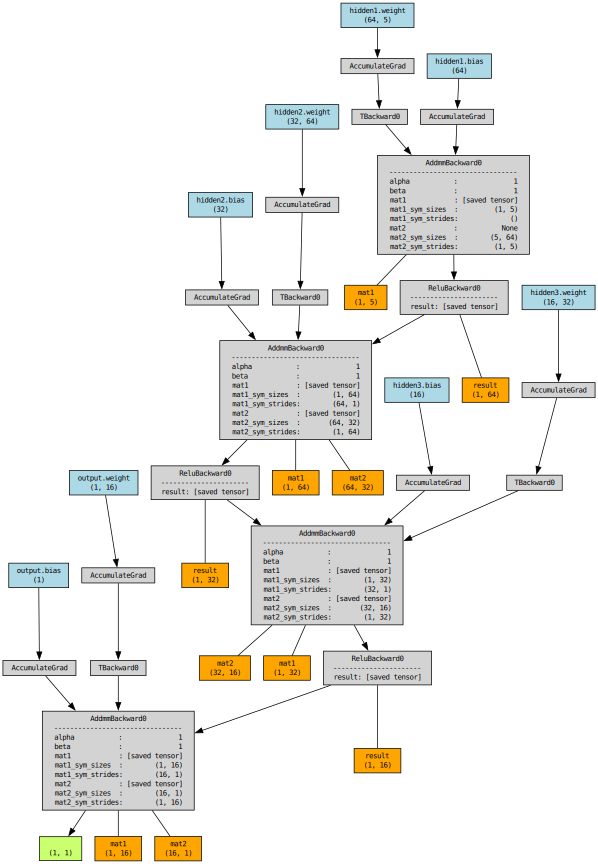

In [204]:
# Define MLP model
class MLP(nn.Module):
    def __init__(self, input_size):
        super(MLP, self).__init__()
        self.hidden1 = nn.Linear(input_size, 64)
        self.hidden2 = nn.Linear(64, 32)
        self.hidden3 = nn.Linear(32, 16)
        self.output = nn.Linear(16, 1)
        self.activation = nn.ReLU()
        #self.activation = nn.Identity()
    
    def forward(self, x):
        x = self.activation(self.hidden1(x))
        x = self.activation(self.hidden2(x))
        x = self.activation(self.hidden3(x))
        x = self.output(x)
        return x

# Initialize model
model = MLP(input_size=X_train.shape[1])

# Create a dummy input to visualize the structure
sample_input = torch.randn(1, X_train.shape[1])  # Batch size = 1, feature size = 5
output = model(sample_input)

# Generate visualization of ONLY the network structure
dot = make_dot(output, params=dict(model.named_parameters()), show_attrs=True, show_saved=True)
dot.render("mlp_network_structure", format="png", cleanup=True)

# Display the graph
dot

In [205]:
from torchsummary import summary
 
print("\nNeural Network Architecture Summary:")
summary(model, input_size=(1, X_train.shape[1]))


Neural Network Architecture Summary:
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Linear-1                [-1, 1, 64]             384
              ReLU-2                [-1, 1, 64]               0
            Linear-3                [-1, 1, 32]           2,080
              ReLU-4                [-1, 1, 32]               0
            Linear-5                [-1, 1, 16]             528
              ReLU-6                [-1, 1, 16]               0
            Linear-7                 [-1, 1, 1]              17
Total params: 3,009
Trainable params: 3,009
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.01
Estimated Total Size (MB): 0.01
----------------------------------------------------------------


### Training

Training Progress:   0%|          | 0/96 [00:00<?, ?it/s]

Epoch 10/96, Train Loss: 0.7461, Val Loss: 0.7442
Epoch 20/96, Train Loss: 0.5026, Val Loss: 0.5114
Epoch 30/96, Train Loss: 0.4162, Val Loss: 0.4526
Epoch 40/96, Train Loss: 0.3795, Val Loss: 0.4384
Epoch 50/96, Train Loss: 0.3557, Val Loss: 0.4089
Epoch 60/96, Train Loss: 0.3484, Val Loss: 0.4265
Epoch 70/96, Train Loss: 0.3371, Val Loss: 0.4043
Epoch 80/96, Train Loss: 0.3046, Val Loss: 0.3925
Epoch 90/96, Train Loss: 0.2933, Val Loss: 0.3944


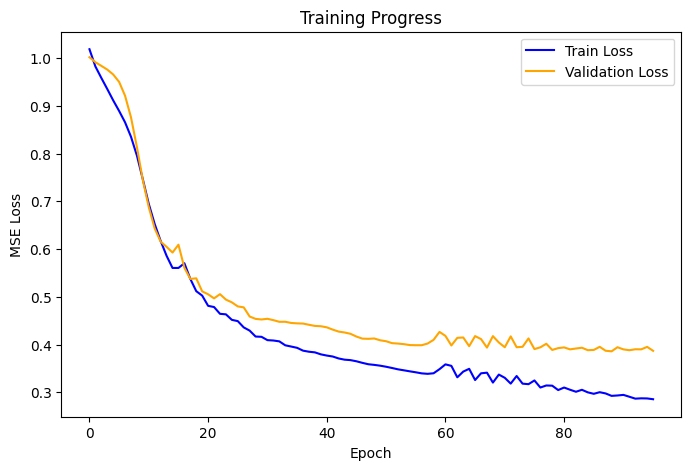

In [206]:

# Define loss function and optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Training loop with tqdm progress bar
num_epochs = 96

train_losses = []
val_losses = []

for epoch in tqdm(range(num_epochs), desc="Training Progress"):
    model.train()
    optimizer.zero_grad()
    
    # Forward pass
    y_pred_train = model(X_train)
    loss = criterion(y_pred_train, y_train)
    
    # Backward pass
    loss.backward()
    optimizer.step()
    
    # Evaluate on validation set
    model.eval()
    with torch.no_grad():
        y_pred_val = model(X_val)
        val_loss = criterion(y_pred_val, y_val)
    
    train_losses.append(loss.item())
    val_losses.append(val_loss.item())

    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{num_epochs}, Train Loss: {loss.item():.4f}, Val Loss: {val_loss.item():.4f}")

# Plot loss curves
plt.figure(figsize=(8, 5))
plt.plot(train_losses, label="Train Loss", color='blue')
plt.plot(val_losses, label="Validation Loss", color='orange')
plt.xlabel("Epoch")
plt.ylabel("MSE Loss")
plt.legend()
plt.title("Training Progress")
plt.show()


### Evaluation of model on data not used for training 

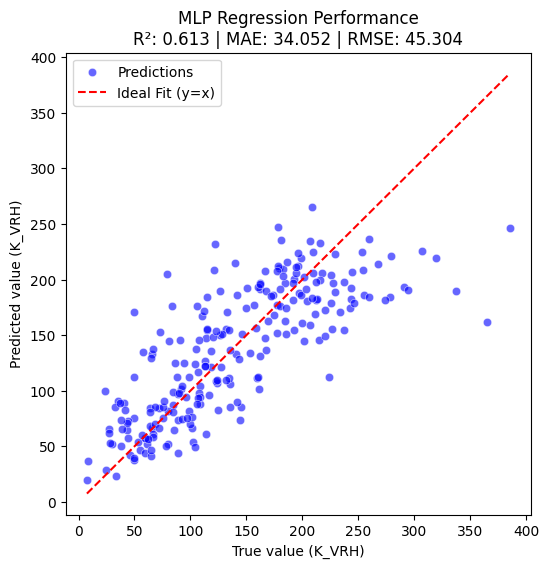

In [207]:
# Evaluate the model on validation set
model.eval()
with torch.no_grad():
    y_pred = model(X_val)

# Convert back to original scale
y_pred = scaler_y.inverse_transform(y_pred.numpy())
y_val = scaler_y.inverse_transform(y_val.numpy())

# Calculate performance metrics
r2 = r2_score(y_val, y_pred)
mae = mean_absolute_error(y_val, y_pred)
rmse = np.sqrt(mean_squared_error(y_val, y_pred))

# Scatter plot with performance metrics
plt.figure(figsize=(6, 6))
sns.scatterplot(x=y_val.flatten(), y=y_pred.flatten(), alpha=0.6, color="blue", label="Predictions")
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], "--", color="red", label="Ideal Fit (y=x)")
plt.xlabel(f"True value ({target})")
plt.ylabel(f"Predicted value ({target})")
plt.title(f"MLP Regression Performance\nR²: {r2:.3f} | MAE: {mae:.3f} | RMSE: {rmse:.3f}")
plt.legend()
plt.show()

#R² Score (r2_score): Measures how well predictions match actual values (1 = perfect, 0 = no relationship).
#Mean Absolute Error (MAE): Average absolute difference between predicted and true values.
#Root Mean Squared Error (RMSE): Measures error magnitude, giving more weight to large errors.